# ✈️ Análise Exploratória de Voos nos EUA (2015)

Este notebook realiza uma análise exploratória completa dos dados de voos domésticos nos Estados Unidos em 2015, com foco em **atrasos de partida e chegada**.

---

## 📦 Datasets Utilizados

| Dataset | Descrição |
|---|---|
| `flights.csv` | ~5,8 milhões de voos domésticos em 2015 |
| `airports.csv` | Informações dos aeroportos (IATA, cidade, estado, lat/long) |
| `airlines.csv` | Nome completo das companhias aéreas |

---

## 🗺️ Perguntas que este notebook responde

1. 📌 Quais aeroportos são mais críticos em relação a atrasos?
2. 🕐 Atrasos são mais comuns em certos dias ou horários?
3. 📅 Qual mês e dia do ano concentra os maiores atrasos?
4. 🏢 Quais companhias aéreas atrasam mais?
5. 🗺️ Existe variação geográfica (estado) nos atrasos?
6. ⚡ Qual a principal causa dos atrasos?
7. 📏 Distância do voo influencia o atraso?

---
## 1. Imports e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Estilo global dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("✅ Imports concluídos.")

C:\Users\Pedro\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✅ Imports concluídos.


---
## 2. Carregamento dos Dados

In [2]:
flights  = pd.read_csv("flights.csv",  low_memory=False)
airports = pd.read_csv("airports.csv")
airlines = pd.read_csv("airlines.csv")

print(f"flights  → {flights.shape[0]:,} linhas × {flights.shape[1]} colunas")
print(f"airports → {airports.shape[0]:,} linhas × {airports.shape[1]} colunas")
print(f"airlines → {airlines.shape[0]:,} linhas × {airlines.shape[1]} colunas")

flights  → 5,819,079 linhas × 31 colunas
airports → 322 linhas × 7 colunas
airlines → 14 linhas × 2 colunas


### Primeiras linhas de `flights`

In [3]:
flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


### Companhias aéreas disponíveis

In [4]:
airlines

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways
5,OO,Skywest Airlines Inc.
6,AS,Alaska Airlines Inc.
7,NK,Spirit Air Lines
8,WN,Southwest Airlines Co.
9,DL,Delta Air Lines Inc.


---
## 3. Qualidade dos Dados

> Antes de qualquer análise, verificamos a **proporção de valores ausentes** por coluna.

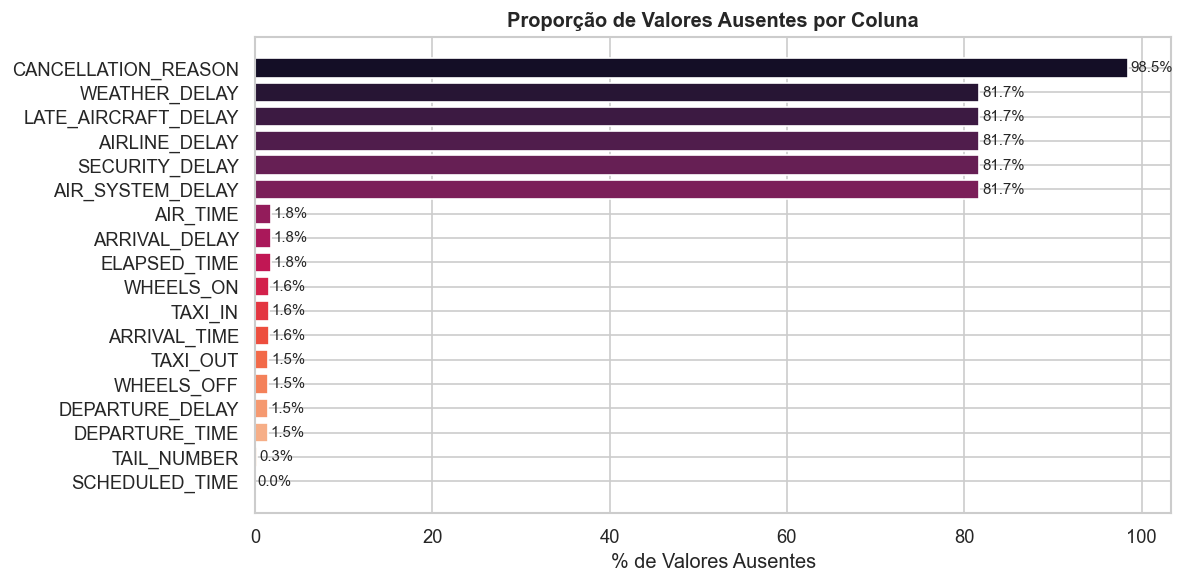


📝 Observações:
  - CANCELLATION_REASON: ~98.5% ausente → preenchido apenas quando o voo é cancelado
  - Colunas de causa de atraso (AIR_SYSTEM_DELAY etc.): ~81.7% ausente → preenchidas
    apenas quando há atraso atribuído a uma causa específica
  - ARRIVAL_DELAY / ELAPSED_TIME: ~1.8% ausente → voos cancelados/desviados


In [5]:
missing = (flights.isna().mean() * 100).sort_values(ascending=False)
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ['Coluna', '% Ausente']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_df['Coluna'], missing_df['% Ausente'],
               color=sns.color_palette('rocket', len(missing_df)))
ax.set_xlabel('% de Valores Ausentes')
ax.set_title('Proporção de Valores Ausentes por Coluna', fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, missing_df['% Ausente']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\n📝 Observações:")
print("  - CANCELLATION_REASON: ~98.5% ausente → preenchido apenas quando o voo é cancelado")
print("  - Colunas de causa de atraso (AIR_SYSTEM_DELAY etc.): ~81.7% ausente → preenchidas")
print("    apenas quando há atraso atribuído a uma causa específica")
print("  - ARRIVAL_DELAY / ELAPSED_TIME: ~1.8% ausente → voos cancelados/desviados")

### Taxa de cancelamento

In [6]:
cancel_rate = flights['CANCELLED'].mean() * 100
diverted_rate = flights['DIVERTED'].mean() * 100

print(f"✈️  Total de voos: {len(flights):,}")
print(f"❌  Voos cancelados: {flights['CANCELLED'].sum():,}  ({cancel_rate:.2f}%)")
print(f"↪️  Voos desviados:  {flights['DIVERTED'].sum():,}  ({diverted_rate:.3f}%)")

✈️  Total de voos: 5,819,079
❌  Voos cancelados: 89,884  (1.54%)
↪️  Voos desviados:  15,187  (0.261%)


---
## 4. Distribuição dos Atrasos

> **DEPARTURE_DELAY** e **ARRIVAL_DELAY** são as variáveis centrais da análise.  
> Valores negativos indicam adiantamento em relação ao horário previsto.

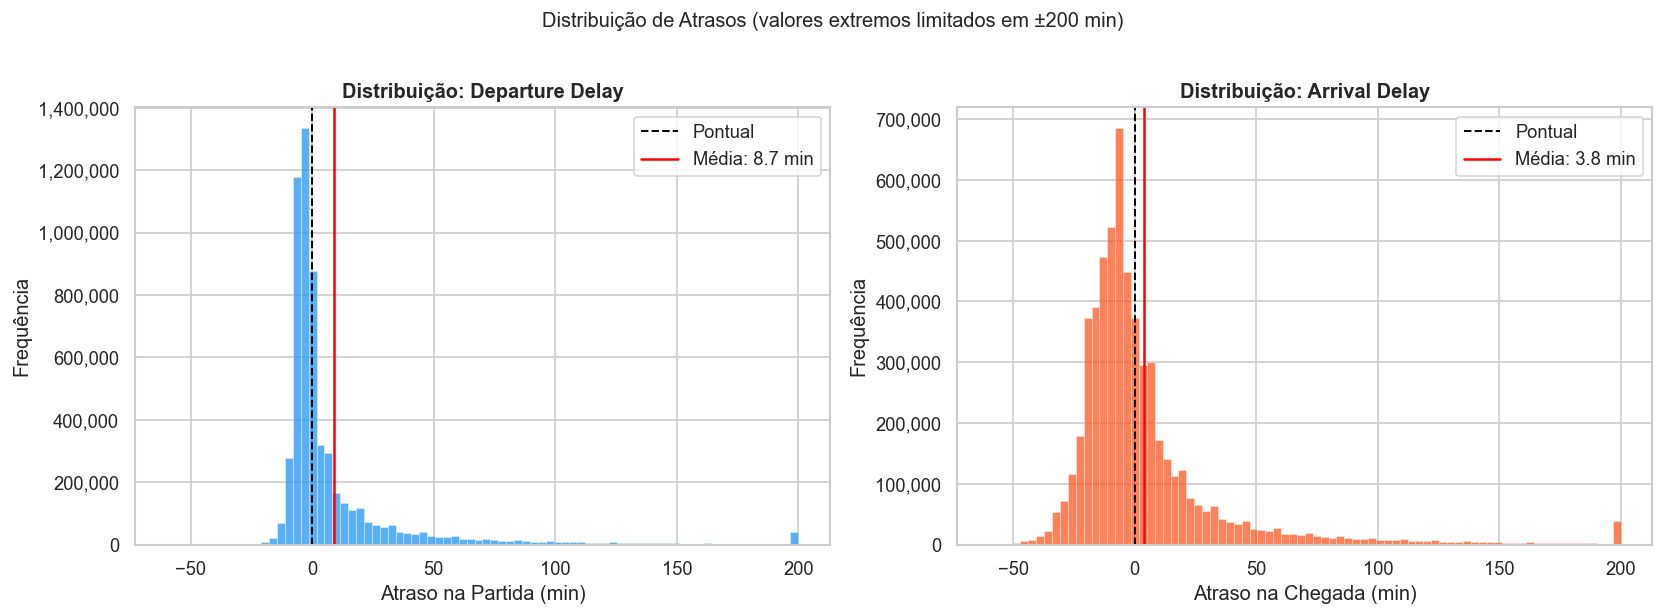

📊 Estatísticas descritivas:
       DEPARTURE_DELAY  ARRIVAL_DELAY
count       5732926.00     5714008.00
mean              9.37           4.41
std              37.08          39.27
min             -82.00         -87.00
25%              -5.00         -13.00
50%              -2.00          -5.00
75%               7.00           8.00
max            1988.00        1971.00


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color, label in zip(
    axes,
    ['DEPARTURE_DELAY', 'ARRIVAL_DELAY'],
    ['#2196F3', '#FF5722'],
    ['Atraso na Partida (min)', 'Atraso na Chegada (min)']
):
    data = flights[col].dropna().clip(-60, 200)
    ax.hist(data, bins=80, color=color, alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.2, label='Pontual')
    ax.axvline(data.mean(), color='red', linestyle='-', linewidth=1.5,
               label=f'Média: {data.mean():.1f} min')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequência')
    ax.set_title(f'Distribuição: {col.replace("_", " ").title()}', fontweight='bold')
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Distribuição de Atrasos (valores extremos limitados em ±200 min)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

print("📊 Estatísticas descritivas:")
print(flights[['DEPARTURE_DELAY','ARRIVAL_DELAY']].describe().round(2))

### Correlação entre atraso de partida e chegada

> Um atraso na partida tende a se propagar para a chegada. Vamos quantificar essa relação.

📈 Correlação de Pearson entre DEPARTURE_DELAY e ARRIVAL_DELAY: 0.9447


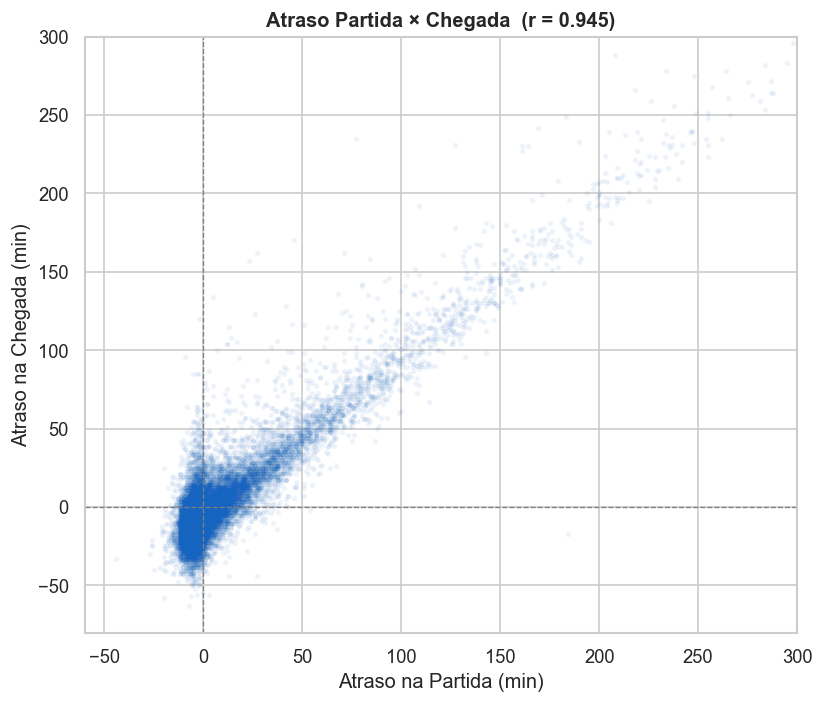

In [8]:
corr = flights[['DEPARTURE_DELAY','ARRIVAL_DELAY']].corr().iloc[0,1]
print(f"📈 Correlação de Pearson entre DEPARTURE_DELAY e ARRIVAL_DELAY: {corr:.4f}")

# Scatter com amostra
sample = flights[['DEPARTURE_DELAY','ARRIVAL_DELAY']].dropna().sample(20000, random_state=42)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sample['DEPARTURE_DELAY'], sample['ARRIVAL_DELAY'],
           alpha=0.05, s=5, color='#1565C0')
ax.set_xlabel('Atraso na Partida (min)')
ax.set_ylabel('Atraso na Chegada (min)')
ax.set_title(f'Atraso Partida × Chegada  (r = {corr:.3f})', fontweight='bold')
ax.set_xlim(-60, 300)
ax.set_ylim(-80, 300)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

---
## 5. Enriquecimento dos Dados

> Fazemos o `merge` de `flights` com `airports` para obter informações geográficas (cidade e estado) de origem e destino.

In [9]:
airport_info = airports[['IATA_CODE','CITY','STATE']].drop_duplicates()

df = flights.merge(
    airport_info.rename(columns={'IATA_CODE':'ORIGIN_AIRPORT','CITY':'ORIGIN_CITY','STATE':'ORIGIN_STATE'}),
    on='ORIGIN_AIRPORT', how='inner'
).merge(
    airport_info.rename(columns={'IATA_CODE':'DESTINATION_AIRPORT','CITY':'DEST_CITY','STATE':'DEST_STATE'}),
    on='DESTINATION_AIRPORT', how='inner'
)

# Flag de atraso significativo (>15 min)
df['IS_DELAYED'] = (df['ARRIVAL_DELAY'] > 15).astype('int8')

# Hora de partida programada
df['DEPARTURE_HOUR'] = (df['SCHEDULED_DEPARTURE'] // 100).astype(int)

print(f"✅ DataFrame enriquecido: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

✅ DataFrame enriquecido: 5,332,914 linhas × 37 colunas


---
## ❓ Pergunta 1 — Quais aeroportos são mais críticos em relação a atrasos?

> Criamos um **score de criticidade** composto por:
> - Atraso médio de chegada
> - Percentual de voos com atraso > 15 min
> - Volume de voos (escala log)
>
> `CRITICAL_SCORE = ARRIVAL_DELAY_mean × 0.5 + PERC_ATRASO × 50 + log(VOLUME + 1)`

In [10]:
airport_stats = df.groupby('ORIGIN_AIRPORT').agg(
    ARRIVAL_DELAY=('ARRIVAL_DELAY', 'mean'),
    DEPARTURE_DELAY=('DEPARTURE_DELAY', 'mean'),
    PERC_ATRASO=('IS_DELAYED', 'mean'),
    VOLUME=('FLIGHT_NUMBER', 'count')
)

airport_stats['CRITICAL_SCORE'] = (
    airport_stats['ARRIVAL_DELAY'] * 0.5
    + airport_stats['PERC_ATRASO'] * 50
    + np.log1p(airport_stats['VOLUME'])
)

# Enriquece com nome do aeroporto
airport_stats = airport_stats.merge(
    airports[['IATA_CODE','AIRPORT','CITY']],
    left_index=True, right_on='IATA_CODE', how='left'
).set_index('IATA_CODE')

top10 = airport_stats.sort_values('CRITICAL_SCORE', ascending=False).head(10)
top10[['CITY','ARRIVAL_DELAY','DEPARTURE_DELAY','PERC_ATRASO','VOLUME','CRITICAL_SCORE']].round(2)

,CITY,ARRIVAL_DELAY,DEPARTURE_DELAY,PERC_ATRASO,VOLUME,CRITICAL_SCORE
IATA_CODE,,,,,,
GST,Gustavus,21.76,17.17,0.43,77,36.67
ILG,Wilmington,24.06,29.39,0.37,100,35.15
PPG,Pago Pago,21.50,15.10,0.29,107,29.92
ASE,Aspen,15.49,17.59,0.26,3562,29.16
STC,St Cloud,19.56,18.69,0.29,83,28.67
ADK,Adak,11.03,10.66,0.36,96,28.32
ORD,Chicago,8.60,14.15,0.23,285884,28.17
BPT,Beaumont/Port Arthur,16.15,17.02,0.23,973,26.57
DEN,Denver,7.19,11.84,0.21,196055,26.44


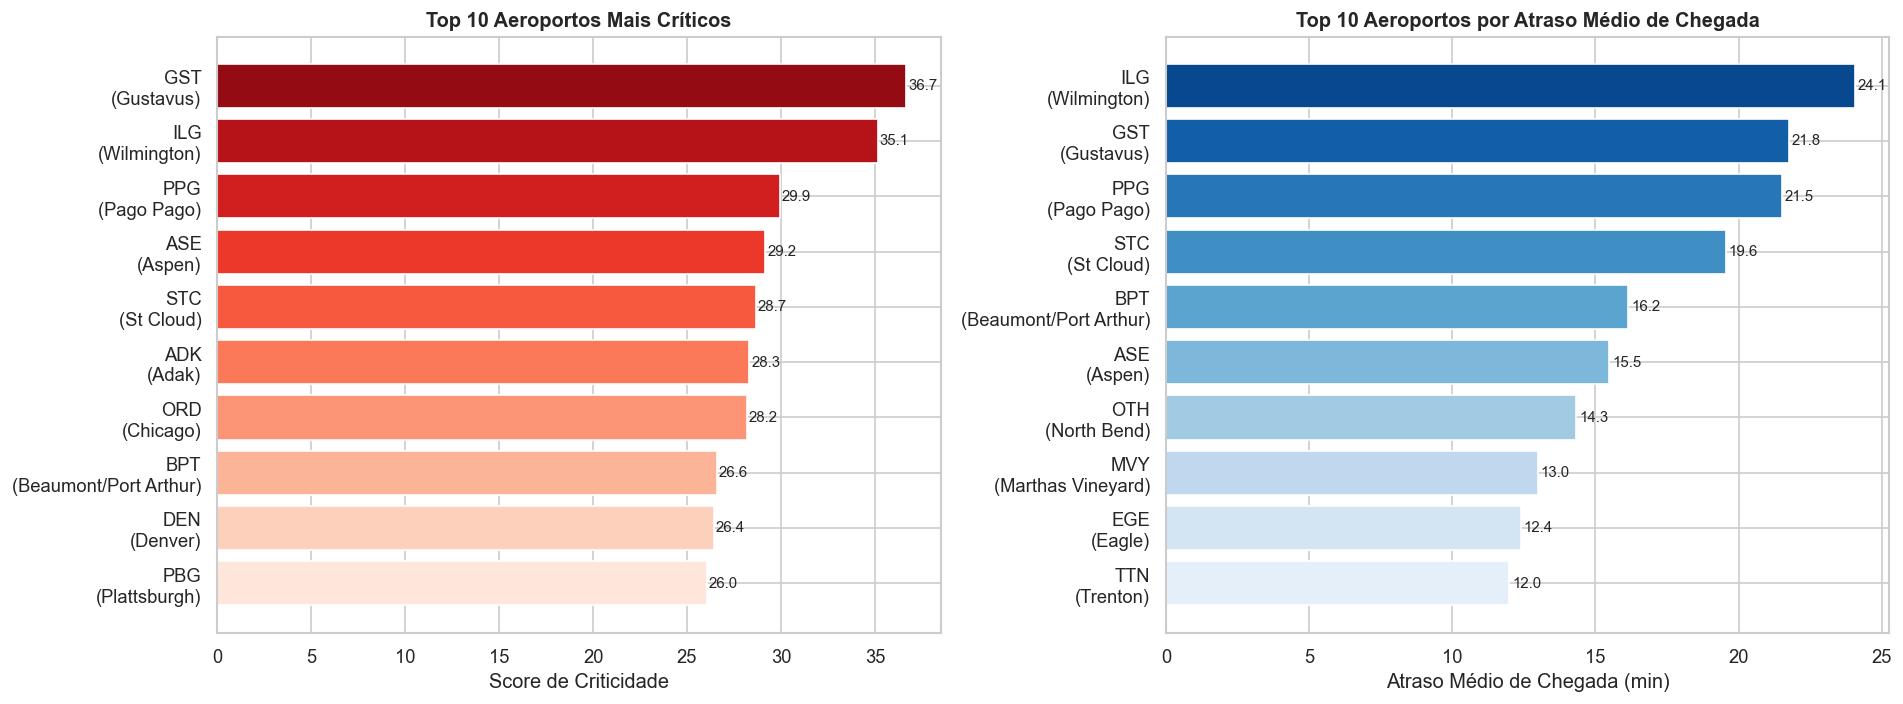

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico 1: Score de criticidade ---
ax = axes[0]
colors = sns.color_palette('Reds_r', len(top10))
bars = ax.barh(
    [f"{idx}\n({row['CITY']})" for idx, row in top10.iterrows()],
    top10['CRITICAL_SCORE'], color=colors
)
ax.set_xlabel('Score de Criticidade')
ax.set_title('Top 10 Aeroportos Mais Críticos', fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, top10['CRITICAL_SCORE']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)

# --- Gráfico 2: Atraso médio de chegada ---
ax2 = axes[1]
top10_arrival = airport_stats.nlargest(10, 'ARRIVAL_DELAY')
colors2 = sns.color_palette('Blues_r', len(top10_arrival))
bars2 = ax2.barh(
    [f"{idx}\n({row['CITY']})" for idx, row in top10_arrival.iterrows()],
    top10_arrival['ARRIVAL_DELAY'], color=colors2
)
ax2.set_xlabel('Atraso Médio de Chegada (min)')
ax2.set_title('Top 10 Aeroportos por Atraso Médio de Chegada', fontweight='bold')
ax2.invert_yaxis()
for bar, val in zip(bars2, top10_arrival['ARRIVAL_DELAY']):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 💡 Insight

> Aeroportos **hub** de grandes metrópoles (Chicago, Nova York, Newark) aparecem frequentemente no topo — combinam **alto volume** com **atrasos consideráveis**, o que os torna os pontos de maior impacto sistêmico na malha aérea.

---
## ❓ Pergunta 2 — Atrasos variam por dia da semana e hora de partida?

> Analisamos a **média de atraso de chegada** cruzando dia da semana (1=Segunda, 7=Domingo) com hora de partida programada.

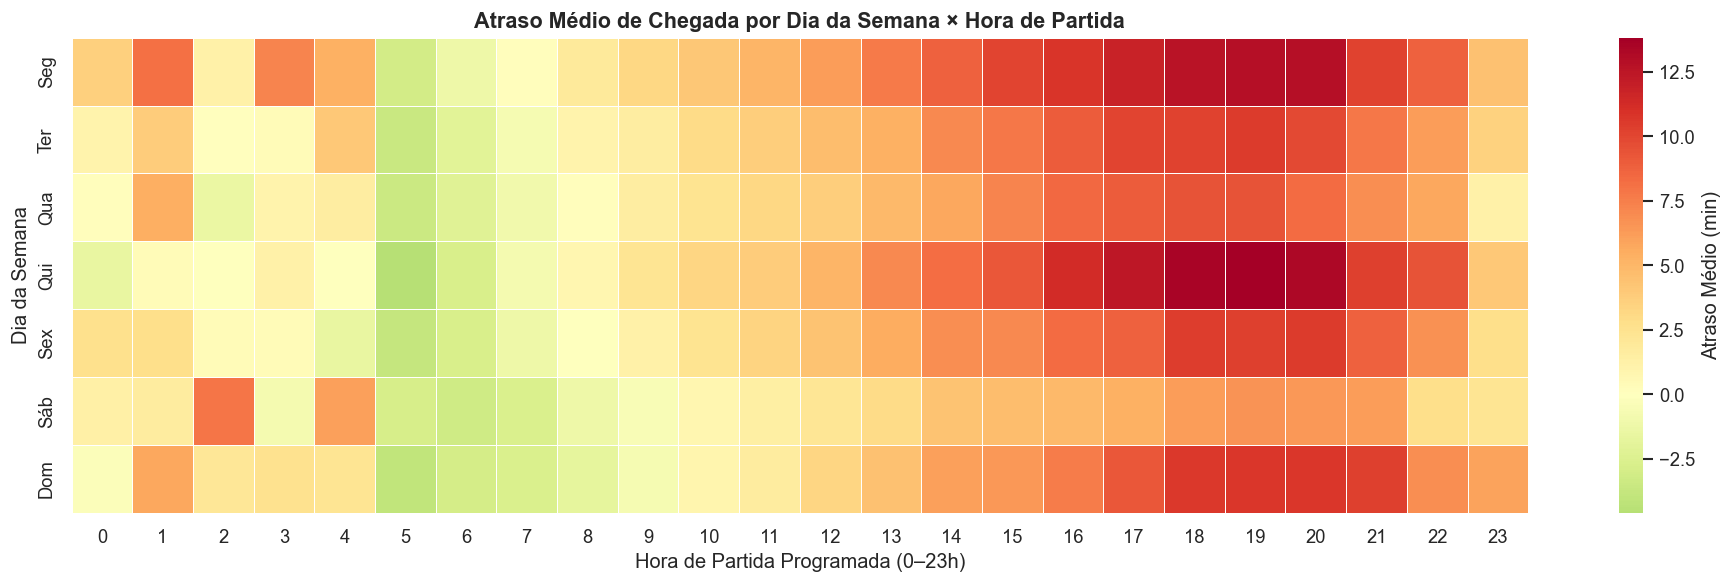

In [12]:
day_map = {1: 'Seg', 2: 'Ter', 3: 'Qua', 4: 'Qui', 5: 'Sex', 6: 'Sáb', 7: 'Dom'}
df['DAY_LABEL'] = df['DAY_OF_WEEK'].map(day_map)

pivot = df.pivot_table(
    values='ARRIVAL_DELAY',
    index='DAY_OF_WEEK',
    columns='DEPARTURE_HOUR',
    aggfunc='mean'
)
pivot.index = [day_map[i] for i in pivot.index]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot, cmap='RdYlGn_r', center=0,
    fmt='.0f', linewidths=0.3,
    cbar_kws={'label': 'Atraso Médio (min)'},
    ax=ax
)
ax.set_title('Atraso Médio de Chegada por Dia da Semana × Hora de Partida', fontweight='bold', fontsize=13)
ax.set_xlabel('Hora de Partida Programada (0–23h)')
ax.set_ylabel('Dia da Semana')
plt.tight_layout()
plt.show()

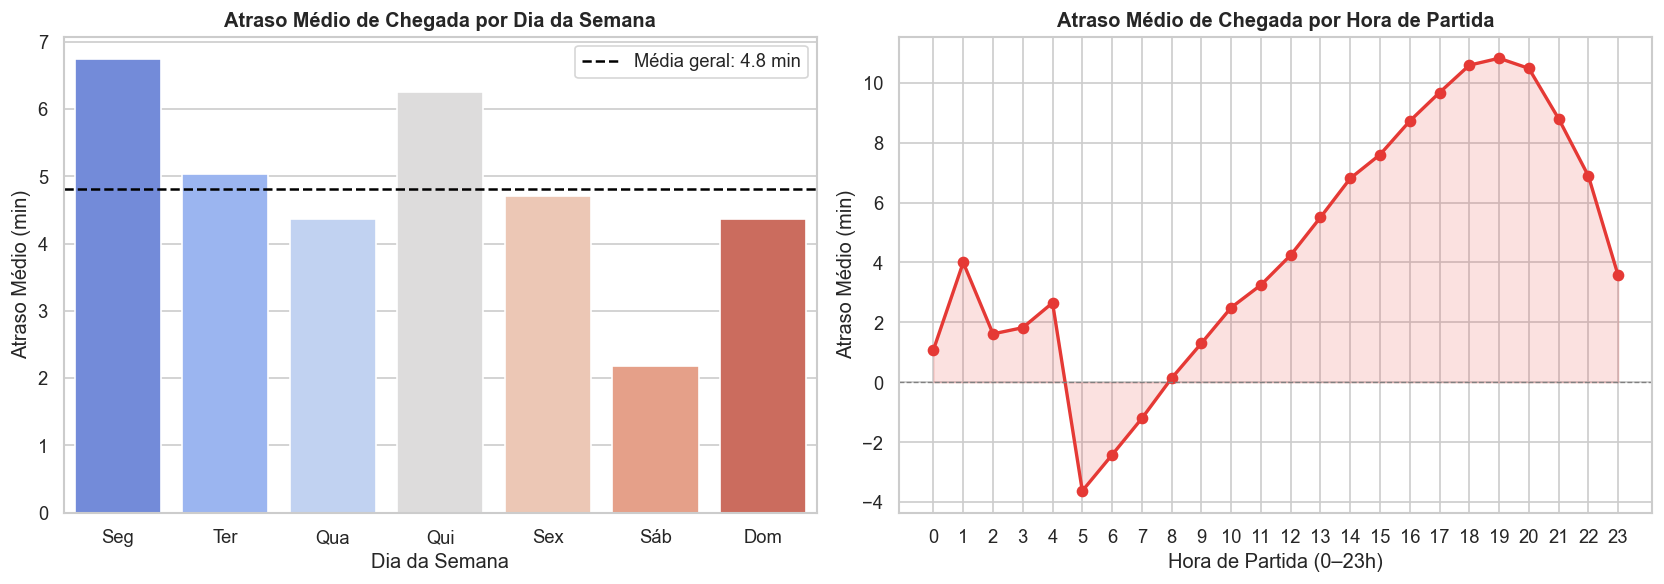

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por dia da semana
day_delay = df.groupby('DAY_OF_WEEK')['ARRIVAL_DELAY'].mean().reindex(range(1, 8))
day_delay.index = [day_map[i] for i in day_delay.index]

sns.barplot(x=day_delay.index, y=day_delay.values, palette='coolwarm', ax=axes[0])
axes[0].set_title('Atraso Médio de Chegada por Dia da Semana', fontweight='bold')
axes[0].set_xlabel('Dia da Semana')
axes[0].set_ylabel('Atraso Médio (min)')
axes[0].axhline(day_delay.mean(), color='black', linestyle='--', label=f'Média geral: {day_delay.mean():.1f} min')
axes[0].legend()

# Por hora
hour_delay = df.groupby('DEPARTURE_HOUR')['ARRIVAL_DELAY'].mean()
#hour_delay = hour_delay[hour_delay.index.between(0, 23)]

axes[1].plot(hour_delay.index, hour_delay.values, marker='o', color='#E53935', linewidth=2)
axes[1].fill_between(hour_delay.index, hour_delay.values, alpha=0.15, color='#E53935')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('Atraso Médio de Chegada por Hora de Partida', fontweight='bold')
axes[1].set_xlabel('Hora de Partida (0–23h)')
axes[1].set_ylabel('Atraso Médio (min)')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

### 💡 Insight

> - **Segundas-feiras** e **quintas-feiras** concentram os maiores atrasos médios da semana.
> - **Sábados** apresentam os menores atrasos — menor volume de operações.
> - Quanto ao horário, voos **noturnos e madrugada** (20h–23h) acumulam atrasos crescentes ao longo do dia. 
>   Voos **matinais** (5h–7h) são os mais pontuais — ponto de partida limpo, sem herança de atraso.

---
## ❓ Pergunta 3 — Qual mês e dia específico concentra os maiores atrasos?

> Identificamos os **piores dias do ano** para voar, medindo o atraso médio de chegada.

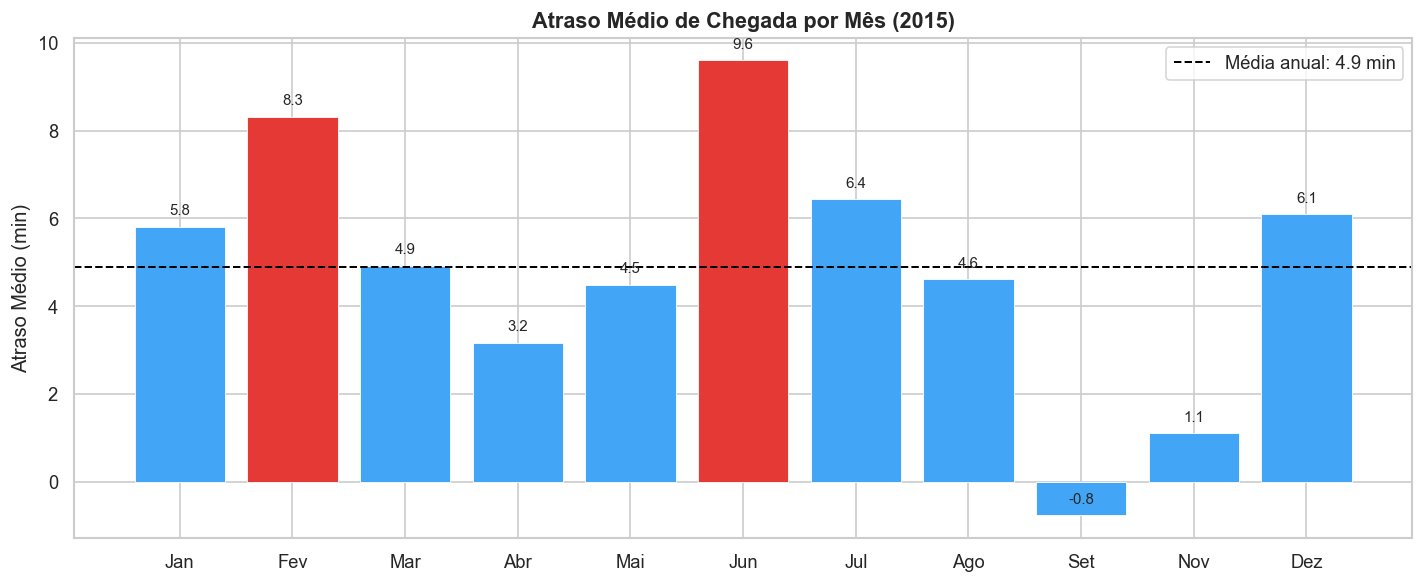

In [15]:
month_map = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
    7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}

monthly = df.groupby('MONTH')['ARRIVAL_DELAY'].mean().sort_index()
monthly.index = [month_map[m] for m in monthly.index]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(monthly.index, monthly.values,
              color=[('#E53935' if v > 8 else '#42A5F5') for v in monthly.values],
              edgecolor='white', linewidth=0.5)
ax.axhline(monthly.mean(), color='black', linestyle='--', linewidth=1.2,
           label=f'Média anual: {monthly.mean():.1f} min')
ax.set_title('Atraso Médio de Chegada por Mês (2015)', fontweight='bold', fontsize=13)
ax.set_ylabel('Atraso Médio (min)')
ax.legend()
for bar, val in zip(bars, monthly.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.2, f'{val:.1f}',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

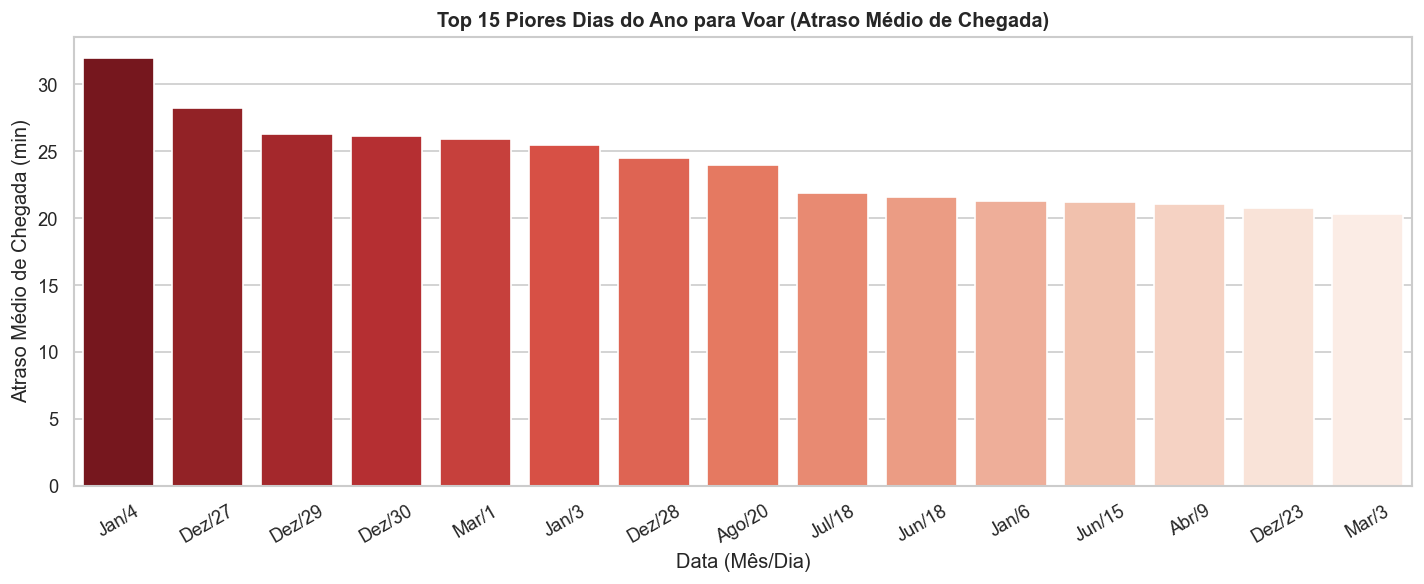

In [16]:
worst_days = (
    df.groupby(['MONTH', 'DAY'])['ARRIVAL_DELAY']
    .mean()
    .reset_index()
    .sort_values('ARRIVAL_DELAY', ascending=False)
    .head(15)
)
worst_days['DATA'] = worst_days['MONTH'].map(month_map) + '/' + worst_days['DAY'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=worst_days, x='DATA', y='ARRIVAL_DELAY',
            palette='Reds_r', ax=ax)
ax.set_title('Top 15 Piores Dias do Ano para Voar (Atraso Médio de Chegada)', fontweight='bold')
ax.set_xlabel('Data (Mês/Dia)')
ax.set_ylabel('Atraso Médio de Chegada (min)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 💡 Insight

> - **Junho** é o pior mês do ano (temporada de verão e início de furacões no Atlântico).
> - **Fevereiro** apresenta atraso médio alto — efeito de tempestades de inverno.
> - **Setembro** é o mês com menor atraso médio da amostra.
> - Os **piores dias individuais** concentram-se em datas de feriados e pós-feriados (Natal, Ano Novo, Páscoa).

---
## ❓ Pergunta 4 — Quais companhias aéreas atrasam mais?

> Comparamos as 14 companhias da base pelo **atraso médio de chegada** e **percentual de voos atrasados**.

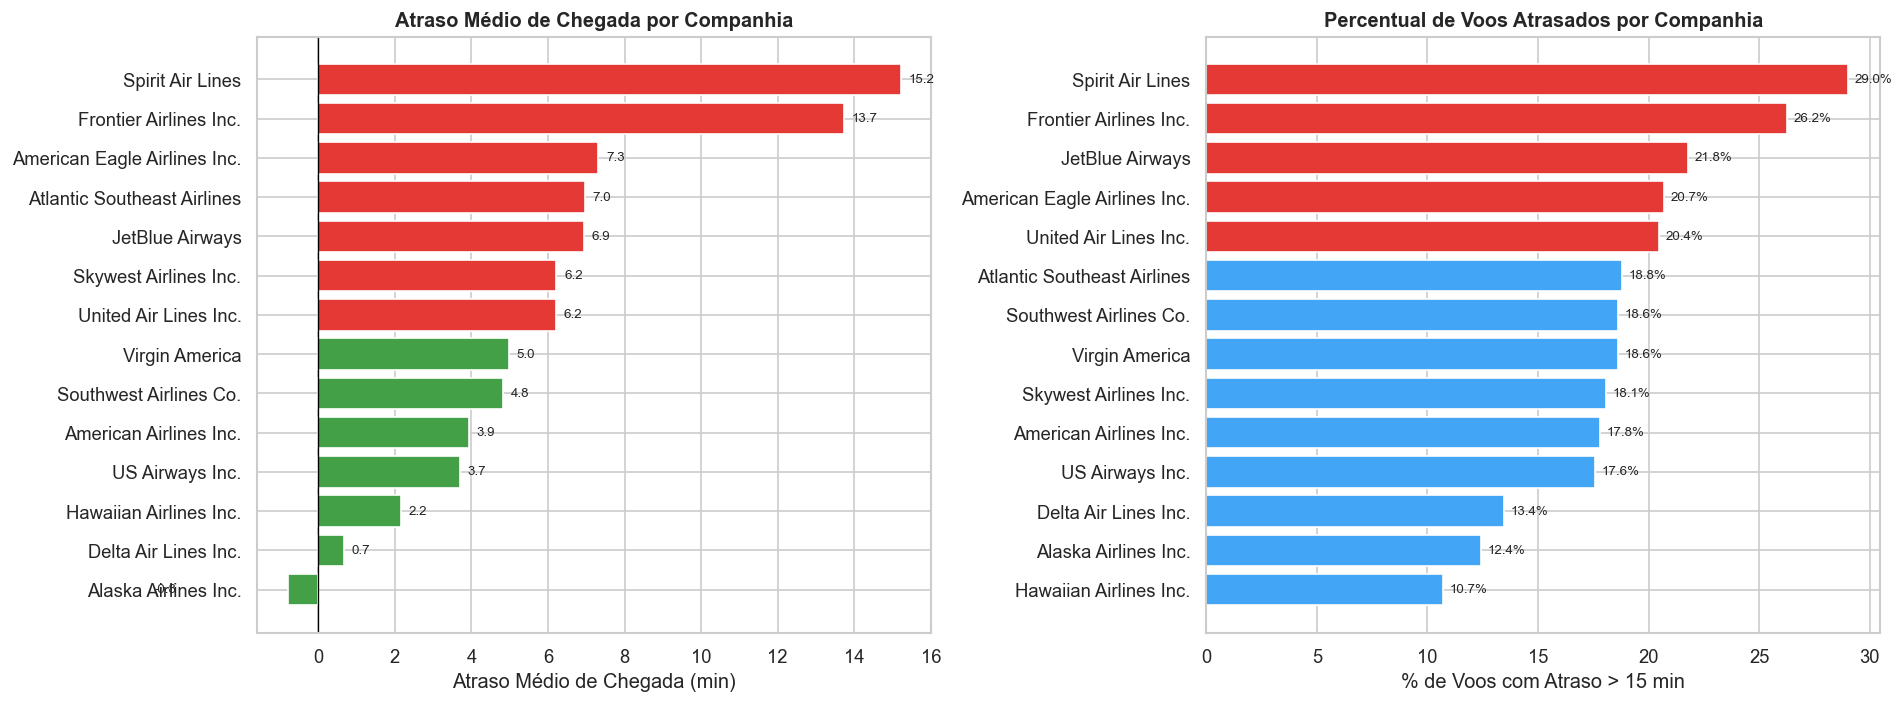

In [23]:
airline_stats = df.groupby('AIRLINE').agg(
    ARRIVAL_DELAY=('ARRIVAL_DELAY', 'mean'),
    DEPARTURE_DELAY=('DEPARTURE_DELAY', 'mean'),
    PERC_DELAYED=('IS_DELAYED', 'mean'),
    VOLUME=('FLIGHT_NUMBER', 'count')
).merge(airlines.rename(columns={'AIRLINE':'AIRLINE_NAME'}).rename(columns={'IATA_CODE': 'AIRLINE'}), on='AIRLINE', how='left')

airline_stats = airline_stats.sort_values('ARRIVAL_DELAY', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Atraso médio de chegada
ax = axes[0]
colors = ['#E53935' if v > 5 else '#43A047' for v in airline_stats['ARRIVAL_DELAY']]
bars = ax.barh(airline_stats['AIRLINE_NAME'], airline_stats['ARRIVAL_DELAY'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Atraso Médio de Chegada (min)')
ax.set_title('Atraso Médio de Chegada por Companhia', fontweight='bold')
for bar, val in zip(bars, airline_stats['ARRIVAL_DELAY']):
    offset = 0.2 if val >= 0 else -3.5
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=8)

# % de voos atrasados
airline_stats2 = airline_stats.sort_values('PERC_DELAYED', ascending=True)
ax2 = axes[1]
colors2 = ['#E53935' if v > 0.2 else '#42A5F5' for v in airline_stats2['PERC_DELAYED']]
bars2 = ax2.barh(airline_stats2['AIRLINE_NAME'], airline_stats2['PERC_DELAYED'] * 100, color=colors2)
ax2.set_xlabel('% de Voos com Atraso > 15 min')
ax2.set_title('Percentual de Voos Atrasados por Companhia', fontweight='bold')
for bar, val in zip(bars2, airline_stats2['PERC_DELAYED'] * 100):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

### 💡 Insight

> - **Spirit Air Lines (NK)** e **Frontier (F9)** lideram em atrasos — companhias *ultra-low-cost* com menor margem operacional.
> - **Alaska Airlines (AS)** e **Hawaiian Airlines (HA)** são consistentemente as mais pontuais
> - **Delta (DL)** tem o melhor desempenho entre as grandes tradicionais.

---
## ❓ Pergunta 5 — Existe variação geográfica (por estado) nos atrasos?

> Analisamos o **atraso médio de partida** por estado de origem.

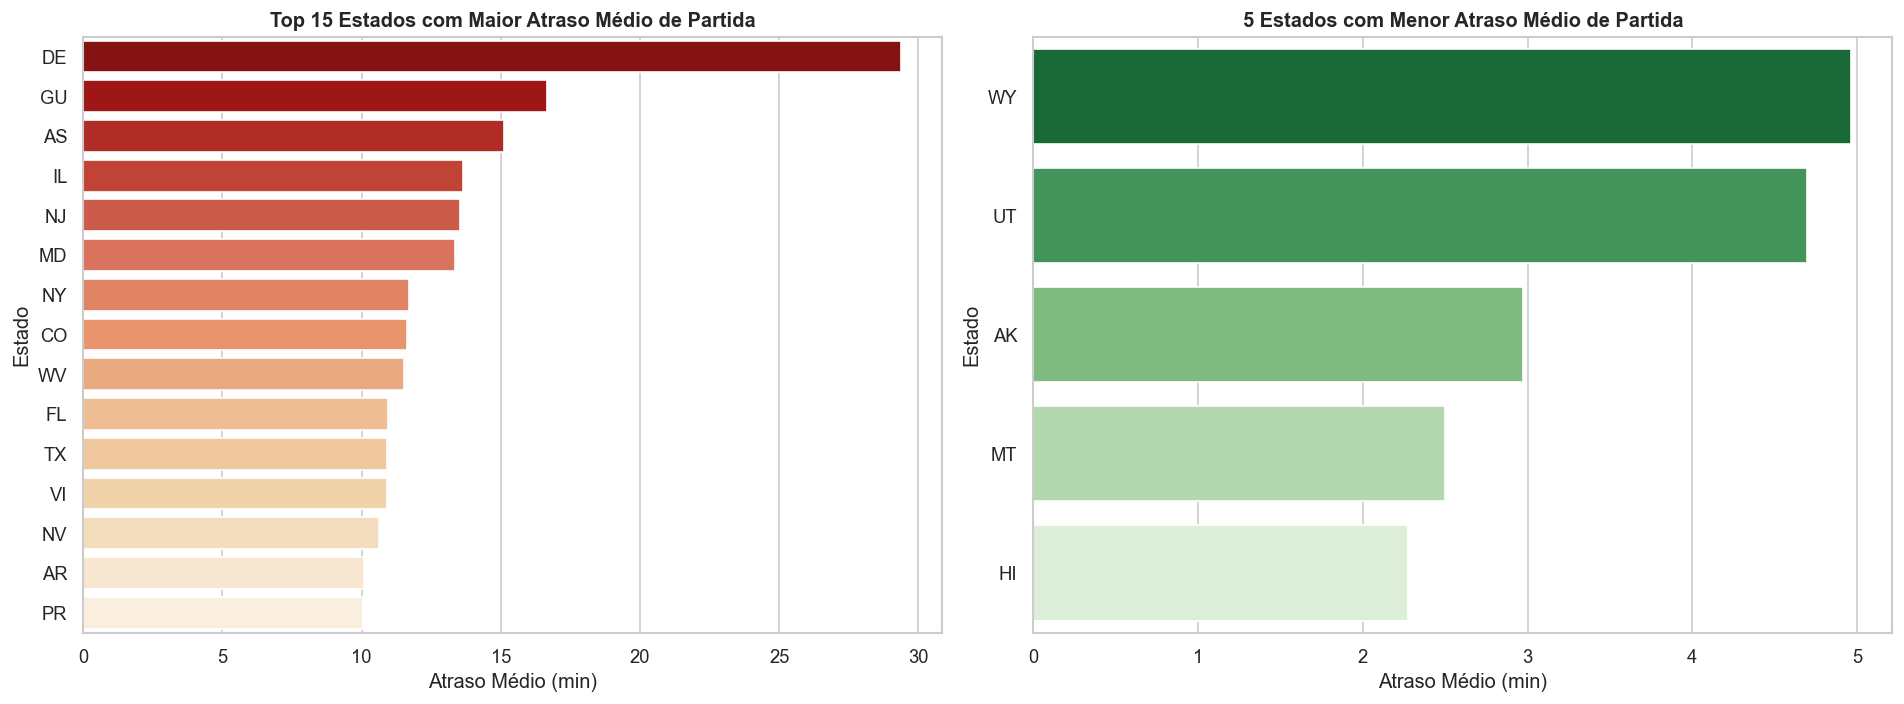

In [24]:
state_delay = (
    df.groupby('ORIGIN_STATE')['DEPARTURE_DELAY']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
state_delay.columns = ['Estado', 'Atraso Médio Partida']

# Top 15 e Bottom 5
top15_state = state_delay.head(15)
best5_state = state_delay.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top15_state, x='Atraso Médio Partida', y='Estado',
            palette='OrRd_r', ax=axes[0])
axes[0].set_title('Top 15 Estados com Maior Atraso Médio de Partida', fontweight='bold')
axes[0].set_xlabel('Atraso Médio (min)')

sns.barplot(data=best5_state, x='Atraso Médio Partida', y='Estado',
            palette='Greens_r', ax=axes[1])
axes[1].set_title('5 Estados com Menor Atraso Médio de Partida', fontweight='bold')
axes[1].set_xlabel('Atraso Médio (min)')

plt.tight_layout()
plt.show()

### 💡 Insight

> - Estados com aeroportos de **grande congestionamento** (Illinois/Chicago, New Jersey/Newark, Maryland/BWI) apresentam os maiores atrasos.
> - Estados com **condições climáticas favoráveis** e menor densidade de tráfego (Montana, Havaí, Alaska) registram os menores atrasos.

---
## ❓ Pergunta 6 — Qual é a principal causa dos atrasos?

> O dataset registra a **causa atribuída** do atraso em 5 categorias:  
> `AIR_SYSTEM_DELAY` | `AIRLINE_DELAY` | `LATE_AIRCRAFT_DELAY` | `WEATHER_DELAY` | `SECURITY_DELAY`
>
> Esses campos só são preenchidos quando há atraso atribuído, portanto excluímos os zeros.

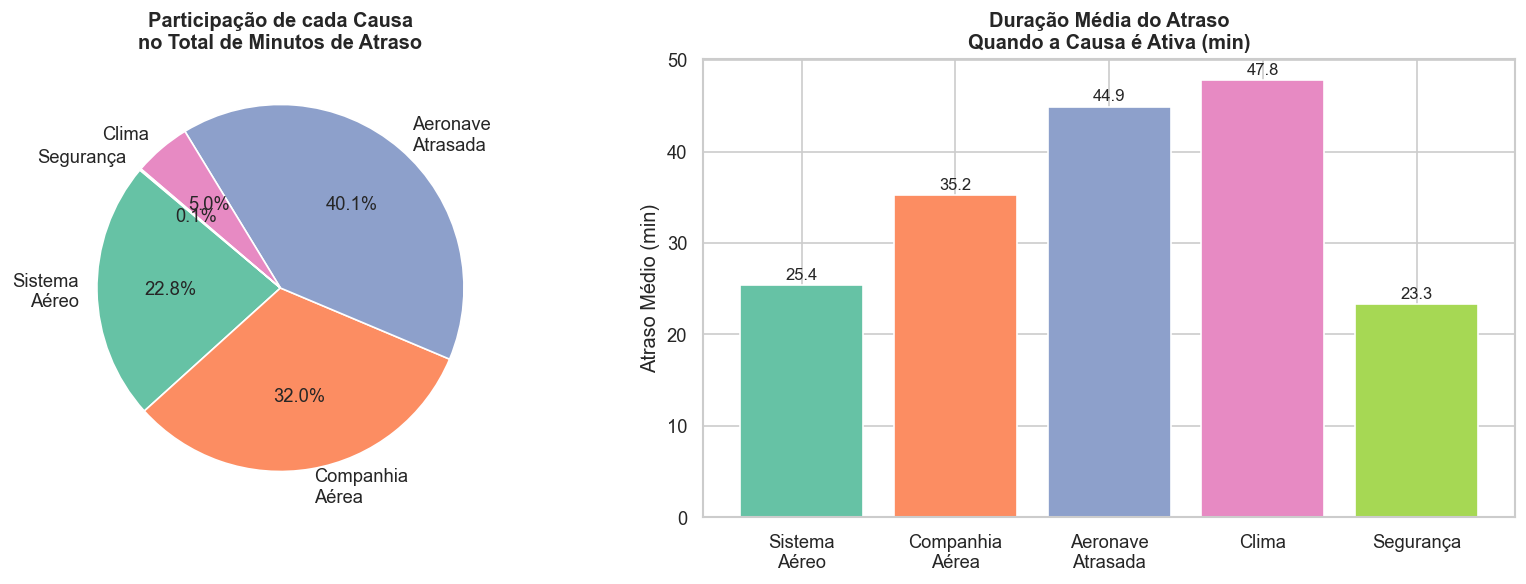

In [25]:
delay_cols = ['AIR_SYSTEM_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'SECURITY_DELAY']
delay_labels = ['Sistema\nAéreo', 'Companhia\nAérea', 'Aeronave\nAtrasada', 'Clima', 'Segurança']

# Total de minutos por causa (excluindo zeros)
cause_totals = df[delay_cols].apply(lambda s: s[s > 0].sum())
cause_means  = df[delay_cols].apply(lambda s: s[s > 0].mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pizza: participação no total de minutos de atraso
axes[0].pie(
    cause_totals,
    labels=delay_labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', 5)
)
axes[0].set_title('Participação de cada Causa\nno Total de Minutos de Atraso', fontweight='bold')

# Barras: atraso médio quando a causa é ativa
colors_bar = sns.color_palette('Set2', 5)
axes[1].bar(delay_labels, cause_means.values, color=colors_bar, edgecolor='white')
axes[1].set_title('Duração Média do Atraso\nQuando a Causa é Ativa (min)', fontweight='bold')
axes[1].set_ylabel('Atraso Médio (min)')
for i, (label, val) in enumerate(zip(delay_labels, cause_means.values)):
    axes[1].text(i, val + 0.3, f'{val:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 💡 Insight

> - **Aeronave atrasada** (*late aircraft*) e **companhia aérea** são as causas que geram mais minutos de atraso no total — efeito dominó da operação.
> - **Clima** é raro em ocorrência, mas quando aparece provoca os **maiores atrasos médios individuais**.
> - **Segurança** é praticamente irrelevante estatisticamente.

---
## ❓ Pergunta 7 — A distância do voo influencia o atraso?

> Investigamos se voos mais longos têm mais ou menos atraso de chegada.

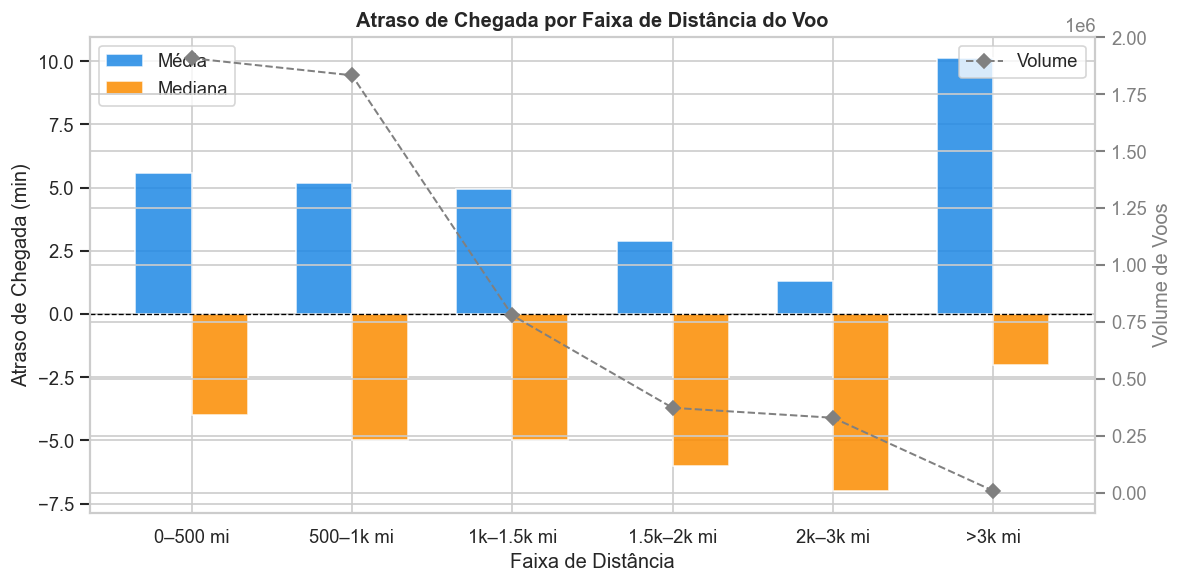


📏 Correlação entre DISTANCE e ARRIVAL_DELAY: -0.0246


In [26]:
# Cria faixas de distância
df['DISTANCE_BIN'] = pd.cut(
    df['DISTANCE'],
    bins=[0, 500, 1000, 1500, 2000, 3000, 6000],
    labels=['0–500 mi', '500–1k mi', '1k–1.5k mi', '1.5k–2k mi', '2k–3k mi', '>3k mi']
)

dist_stats = df.groupby('DISTANCE_BIN', observed=True)['ARRIVAL_DELAY'].agg(['mean', 'median', 'count']).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(dist_stats))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], dist_stats['mean'],
               width=width, label='Média', color='#1E88E5', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], dist_stats['median'],
               width=width, label='Mediana', color='#FB8C00', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(dist_stats['DISTANCE_BIN'])
ax.set_xlabel('Faixa de Distância')
ax.set_ylabel('Atraso de Chegada (min)')
ax.set_title('Atraso de Chegada por Faixa de Distância do Voo', fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend()

# Volume
ax2 = ax.twinx()
ax2.plot(x, dist_stats['count'], 'D--', color='gray', markersize=6, linewidth=1.2, label='Volume')
ax2.set_ylabel('Volume de Voos', color='gray')
ax2.tick_params(axis='y', colors='gray')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"\n📏 Correlação entre DISTANCE e ARRIVAL_DELAY: {df[['DISTANCE','ARRIVAL_DELAY']].corr().iloc[0,1]:.4f}")

### 💡 Insight

> - A **correlação entre distância e atraso é quase zero** (≈ -0.02), indicando pouca relação linear direta.
> - Voos **muito curtos (0–500 mi)** são os que mais atrasam em média — hubs lotados e menor tempo disponível para recuperação.
> - Voos **muito longos (>3k mi)** tendem a chegar ligeiramente **antes do previsto** — buffers maiores no planejamento.

---
## 📋 Resumo dos Insights

| # | Pergunta | Insight Principal |
|---|---|---|
| 1 | Aeroportos críticos | Hubs de Chicago e NY dominam pelo volume + atraso combinados |
| 2 | Dia/hora | Segundas-feiras e voos noturnos têm maiores atrasos |
| 3 | Mês/dia | Junho é o pior mês; feriados concentram os piores dias |
| 4 | Companhias | Spirit e Frontier atrasam mais; Alaska e Hawaiian são as melhores |
| 5 | Geografia | Illinois, New Jersey e Maryland lideram os atrasos por estado |
| 6 | Causas | Aeronave atrasada e operação da companhia são as maiores causas |
| 7 | Distância | Pouca correlação; voos curtos atrasam mais, longos chegam antes |

---

## 🎯 Possíveis Features para Modelagem Preditiva

> Com base na análise exploratória, as variáveis mais promissoras para prever atrasos são:

- **Temporal**: `MONTH`, `DAY_OF_WEEK`, `DEPARTURE_HOUR`
- **Operacional**: `AIRLINE`, `ORIGIN_AIRPORT`, `DESTINATION_AIRPORT`
- **Geográfico**: `ORIGIN_STATE`, `DEST_STATE`
- **Estrutural**: `DISTANCE`, `SCHEDULED_TIME`